# CloudMind RAG — Sprint 4 Embedding Models Evaluation
## Part A: Infrastructure Benchmark + Part B: Retrieval Quality

This notebook visualizes the Sprint 4 evaluation comparing three embedding models —
nomic-embed-text-v1.5, BAAI/bge-m3, and Qwen3-Embedding-0.6B — across infrastructure
performance (Part A) and retrieval quality metrics against a manually annotated
ground truth (Part B).

## 1. Load Results

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load Part A — infrastructure benchmark
with open("../results/benchmarks/embedding_benchmark_results.json", "r") as f:
    part_a_results = json.load(f)
df_a = pd.DataFrame(part_a_results)

# Load Part B — retrieval quality
with open("../results/benchmarks/retrieval_evaluation_results.json", "r") as f:
    part_b_results = json.load(f)
df_b = pd.DataFrame(part_b_results)

k = int(df_b["top_k"].iloc[0])

print("Results loaded successfully")
print(f"Models evaluated: {[m.split('/')[-1] for m in df_a['model']]}")

Results loaded successfully
Models evaluated: ['nomic-embed-text-v1.5', 'bge-m3', 'Qwen3-Embedding-0.6B']


## 2. Part A — Infrastructure Comparison Table

In [6]:
display_a = df_a[["model", "n_documents", "embedding_time_s", "indexing_time_s",
                  "avg_search_time_s", "p95_latency_s", "throughput_qps", "avg_similarity_score"]].copy()

display_a["model"] = display_a["model"].apply(lambda m: m.split("/")[-1])

display_a.columns = [
    "Model", "Documents", "Embed (s)", "Index (s)",
    "Search (s)", "P95 (s)", "QPS", "Similarity"
]

display_a = display_a.set_index("Model")

display_a

,Documents,Embed (s),Index (s),Search (s),P95 (s),QPS,Similarity
Model,,,,,,,
nomic-embed-text-v1.5,7219,219.4106,8.7531,0.0161,0.0299,62.17,0.7509
bge-m3,7219,110.2389,7.9422,0.0211,0.0311,47.34,0.6590
Qwen3-Embedding-0.6B,7219,357.2363,8.9300,0.0151,0.0262,66.08,0.6888


## 3. Part A — Infrastructure Charts

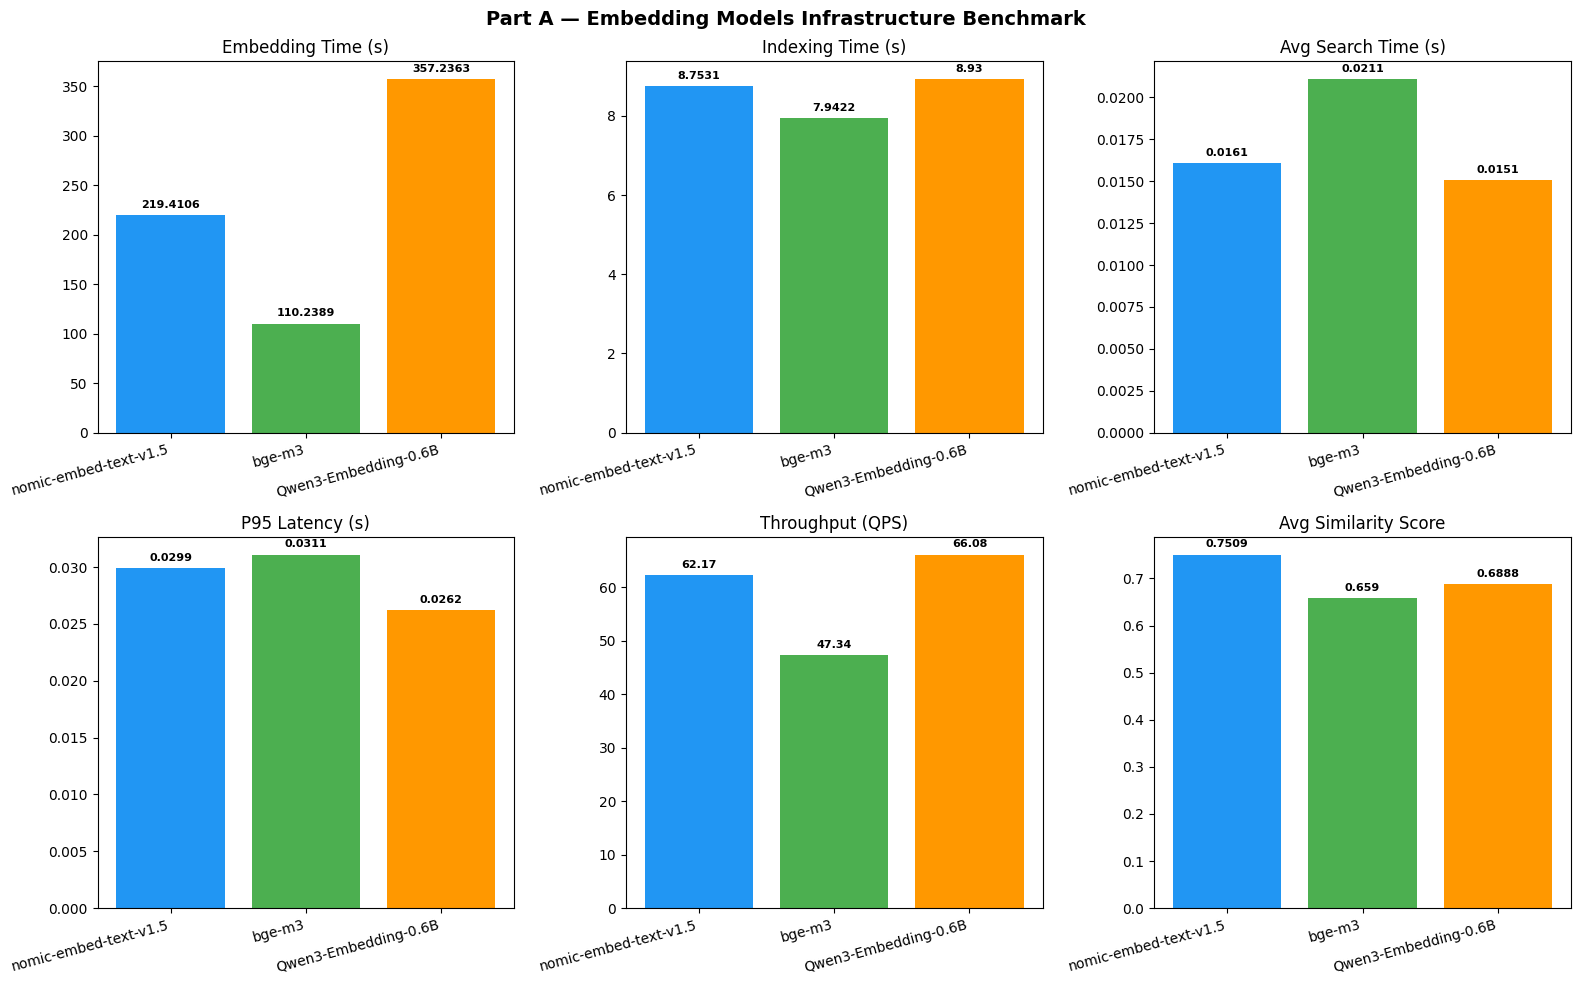

✅ Chart saved to results/benchmarks/embedding_benchmark_chart.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Part A — Embedding Models Infrastructure Benchmark", fontsize=14, fontweight="bold")

models_short = [m.split("/")[-1] for m in df_a["model"]]
colors = ["#2196F3", "#4CAF50", "#FF9800"]

metrics_a = [
    ("embedding_time_s", "Embedding Time (s)", axes[0, 0]),
    ("indexing_time_s", "Indexing Time (s)", axes[0, 1]),
    ("avg_search_time_s", "Avg Search Time (s)", axes[0, 2]),
    ("p95_latency_s", "P95 Latency (s)", axes[1, 0]),
    ("throughput_qps", "Throughput (QPS)", axes[1, 1]),
    ("avg_similarity_score", "Avg Similarity Score", axes[1, 2]),
]

for col, title, ax in metrics_a:
    values = df_a[col]
    ax.bar(models_short, values, color=colors)
    ax.set_title(title)
    offset = values.max() * 0.02
    for i, v in enumerate(values):
        ax.text(i, v + offset, str(v), ha="center", fontweight="bold", fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

plt.tight_layout()
plt.savefig("../results/benchmarks/embedding_benchmark_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to results/benchmarks/embedding_benchmark_chart.png")

## 4. Part B — Retrieval Quality Comparison Table

In [9]:
recall_col = f"recall_at_{k}"
ndcg_col = f"ndcg_at_{k}"

display_b = df_b[["model", "n_queries", recall_col, "mrr", ndcg_col]].copy()

display_b["model"] = display_b["model"].apply(lambda m: m.split("/")[-1])

display_b.columns = ["Model", "Queries", f"Recall@{k}", "MRR", f"NDCG@{k}"]

display_b = display_b.set_index("Model")

display_b

,Queries,Recall@5,MRR,NDCG@5
Model,,,,
nomic-embed-text-v1.5,10,0.7,0.4233,0.4905
bge-m3,10,0.7,0.5500,0.5893
Qwen3-Embedding-0.6B,10,0.5,0.3533,0.3887


## 5. Part B — Retrieval Quality Charts

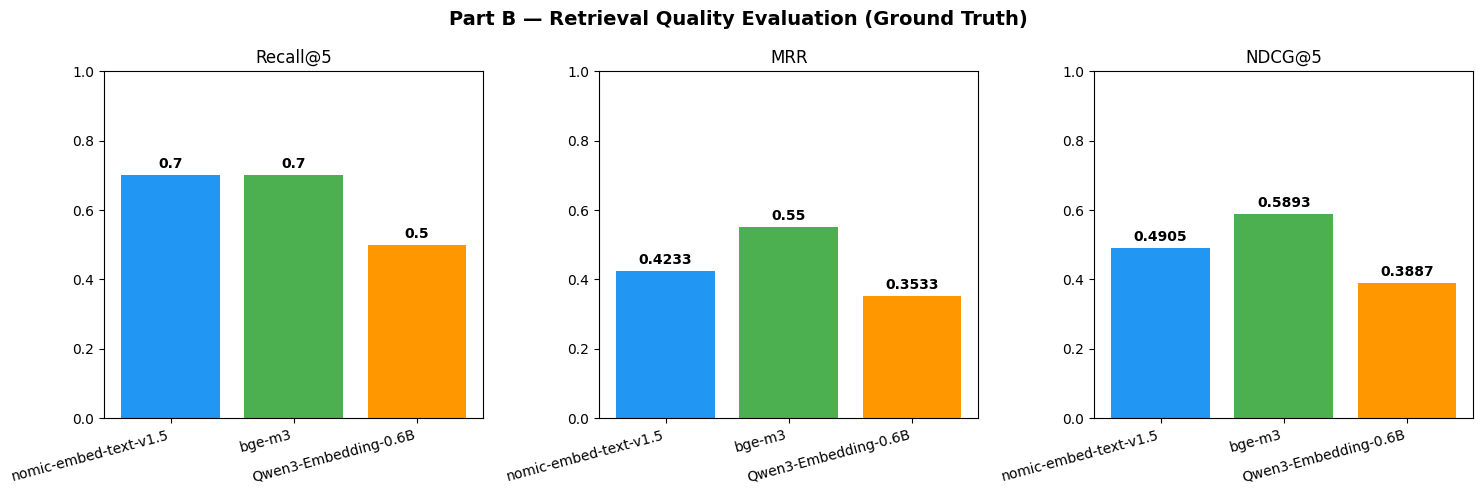

✅ Chart saved to results/benchmarks/retrieval_evaluation_chart.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Part B — Retrieval Quality Evaluation (Ground Truth)", fontsize=14, fontweight="bold")

metrics_b = [
    (recall_col, f"Recall@{k}", axes[0]),
    ("mrr", "MRR", axes[1]),
    (ndcg_col, f"NDCG@{k}", axes[2]),
]

for col, title, ax in metrics_b:
    values = df_b[col]
    ax.bar(models_short, values, color=colors)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    for i, v in enumerate(values):
        ax.text(i, v + 0.02, str(v), ha="center", fontweight="bold")
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

plt.tight_layout()
plt.savefig("../results/benchmarks/retrieval_evaluation_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to results/benchmarks/retrieval_evaluation_chart.png")

In [11]:
print("=" * 55)
print("CLOUDMIND — EMBEDDING MODELS EVALUATION CONCLUSION")
print("=" * 55)

print(f"""
Dataset      : {df_a['n_documents'].iloc[0]:,} chunks
Ground truth : {df_b['n_queries'].iloc[0]} annotated queries

PART A — INFRASTRUCTURE
""")
for _, row in df_a.iterrows():
    model = row["model"].split("/")[-1]
    print(f"  {model:<25} embed {row['embedding_time_s']}s | search {row['avg_search_time_s']}s | QPS {row['throughput_qps']} | similarity {row['avg_similarity_score']}")

print(f"""
PART B — RETRIEVAL QUALITY
""")
for _, row in df_b.iterrows():
    model = row["model"].split("/")[-1]
    print(f"  {model:<25} Recall@{k} {row[recall_col]} | MRR {row['mrr']} | NDCG@{k} {row[ndcg_col]}")

print(f"""
VERDICT FOR CLOUDMIND PRODUCTION
  -> BAAI/bge-m3 selected: best MRR/NDCG (real ranking quality),
     tied for top Recall@{k}, and 2x faster embedding than nomic-v1.5.
  -> avg_similarity_score alone was misleading (favored nomic-v1.5)
     which is exactly why Part B (ground truth based) was necessary.
""")

CLOUDMIND — EMBEDDING MODELS EVALUATION CONCLUSION

Dataset      : 7,219 chunks
Ground truth : 10 annotated queries

PART A — INFRASTRUCTURE

  nomic-embed-text-v1.5     embed 219.4106s | search 0.0161s | QPS 62.17 | similarity 0.7509
  bge-m3                    embed 110.2389s | search 0.0211s | QPS 47.34 | similarity 0.659
  Qwen3-Embedding-0.6B      embed 357.2363s | search 0.0151s | QPS 66.08 | similarity 0.6888

PART B — RETRIEVAL QUALITY

  nomic-embed-text-v1.5     Recall@5 0.7 | MRR 0.4233 | NDCG@5 0.4905
  bge-m3                    Recall@5 0.7 | MRR 0.55 | NDCG@5 0.5893
  Qwen3-Embedding-0.6B      Recall@5 0.5 | MRR 0.3533 | NDCG@5 0.3887

VERDICT FOR CLOUDMIND PRODUCTION
  -> BAAI/bge-m3 selected: best MRR/NDCG (real ranking quality),
     tied for top Recall@5, and 2x faster embedding than nomic-v1.5.
  -> avg_similarity_score alone was misleading (favored nomic-v1.5)
     which is exactly why Part B (ground truth based) was necessary.



### Decision

For the production of CloudMind, we have decided to use **BAAI/bge-m3** as our embedding model.

While `avg_similarity_score` alone (Part A) suggested nomic-embed-text-v1.5 was the stronger
model (0.7509 vs 0.659), this metric only measures vector proximity within each model's own
embedding space and is not comparable across models. Part B's ground-truth based evaluation —
Recall@5, MRR, and NDCG@5 — tells a different and more reliable story:

- **MRR** — bge-m3 places the correct document earlier in the ranking (0.55 vs 0.42 for nomic).
- **NDCG@5** — bge-m3 produces meaningfully better overall ranking quality (0.59 vs 0.49).
- **Recall@5** — bge-m3 ties nomic-v1.5 for the best score (0.7), so no quality is sacrificed.
- **Embedding speed** — bge-m3 embeds the corpus 2x faster than nomic-v1.5 (110s vs 219s).
- **Multilingual support** — bge-m3 is natively multilingual, matching CloudMind's FR/EN usage.

Qwen3-Embedding-0.6B was evaluated as a lightweight challenger but underperformed on every
retrieval quality metric and was also the slowest to embed, so it was not retained.

This confirms the value of Part B: relying on `avg_similarity_score` alone would have led to
selecting the wrong model for production.